Summarize a long text document into a concise and coherent abstract using LangChain's tools and pipelines.

In [1]:
from getpass import getpass

OPENAI_KEY = getpass('Enter Open AI API Key: ')

In [2]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY

In [8]:
from langchain.text_splitter import CharacterTextSplitter
from langchain.prompts import PromptTemplate
from langchain.llms import OpenAI
from langchain.chains.summarize.chain import load_summarize_chain

In [4]:
input_text = """ 
LangChain is a framework for building applications powered by large language models (LLMs). 
It simplifies the development of workflows by providing modular components for tasks like text generation, 
summarization, and knowledge retrieval. LangChain supports integration with external tools such as APIs 
and databases, allowing you to create dynamic and context-aware applications. Its key fea-tures include 
memory management for conversational agents, retrieval-augmented generation (RAG), and support for custom tools. You widely use LangChain for building chatbots, summarization tools, and knowledge-based 
applications. """

In [23]:
# Split the Input Text in Chunks

from langchain.text_splitter import RecursiveCharacterTextSplitter

splitter = CharacterTextSplitter(chunk_size=100, chunk_overlap=20)

# Split the input text

chunks = splitter.split_text(input_text)
print("Text Chunks", chunks)

Text Chunks ['LangChain is a framework for building applications powered by large language models (LLMs). \nIt simplifies the development of workflows by providing modular components for tasks like text generation, \nsummarization, and knowledge retrieval. LangChain supports integration with external tools such as APIs \nand databases, allowing you to create dynamic and context-aware applications. Its key fea-tures include \nmemory management for conversational agents, retrieval-augmented generation (RAG), and support for custom tools. You widely use LangChain for building chatbots, summarization tools, and knowledge-based \napplications.']


In [24]:
# Define the Prompt Template

prompt = PromptTemplate(
    input_variables= ["text"],
    template= "Summarize the following text: {text}")

In [25]:
llm = OpenAI(model = 'gpt-3.5-turbo-instruct',temperature=0.7)

In [26]:
from langchain.chains import LLMChain

summarization_chain = LLMChain(llm=llm, prompt=prompt,verbose=True)

summaries = [summarization_chain.run({"text": chunk}) for chunk in chunks]



> Entering new LLMChain chain...
Prompt after formatting:
Summarize the following text: LangChain is a framework for building applications powered by large language models (LLMs). 
It simplifies the development of workflows by providing modular components for tasks like text generation, 
summarization, and knowledge retrieval. LangChain supports integration with external tools such as APIs 
and databases, allowing you to create dynamic and context-aware applications. Its key fea-tures include 
memory management for conversational agents, retrieval-augmented generation (RAG), and support for custom tools. You widely use LangChain for building chatbots, summarization tools, and knowledge-based 
applications.

> Finished chain.


In [27]:
final_summary = " ".join(summaries)
print(final_summary)



LangChain is a framework that makes it easier to create applications using large language models. It offers modular components for tasks like text generation and summarization, and can integrate with external tools. Its features include memory management for chatbots, retrieval-augmented generation, and support for custom tools. LangChain is commonly used for building chatbots, summarization tools, and knowledge-based applications.


In [28]:
# Run Summarization on whole text
summarization_chain.invoke(input_text)



> Entering new LLMChain chain...
Prompt after formatting:
Summarize the following text:  
LangChain is a framework for building applications powered by large language models (LLMs). 
It simplifies the development of workflows by providing modular components for tasks like text generation, 
summarization, and knowledge retrieval. LangChain supports integration with external tools such as APIs 
and databases, allowing you to create dynamic and context-aware applications. Its key fea-tures include 
memory management for conversational agents, retrieval-augmented generation (RAG), and support for custom tools. You widely use LangChain for building chatbots, summarization tools, and knowledge-based 
applications. 

> Finished chain.


{'text': '\n\nLangChain is a framework that utilizes large language models to build applications. Its modular components make it easy to create text generation, summarization, and knowledge retrieval workflows. It also supports integration with external tools for dynamic and context-aware applications, and its key features include memory management, RAG, and custom tool support. LangChain is commonly used for chatbots, summarization tools, and knowledge-based applications.'}

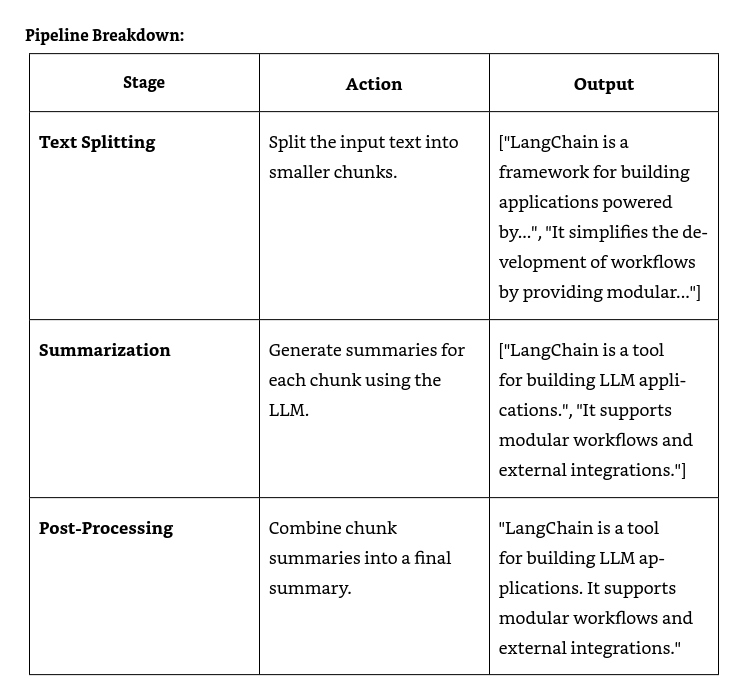